# 📊 Exploración del Dataset SafeTalk

**Objetivo:** Analizar y entender el dataset de detección de bullying/hate speech

**Dataset:** dataset_safetalk_completo.csv
- Fuentes: Zenodo (OffendES) + Kaggle (Cyberbullying traducido)
- Idioma: Español
- Clases: 0 (No ofensivo) / 1 (Ofensivo/Bullying)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print(" Librerías cargadas correctamente")

 Librerías cargadas correctamente


## 1. Cargar Dataset

In [2]:
dataset_path = Path('../data/processed/dataset_safetalk_completo.csv')

# Cargar
df = pd.read_csv(dataset_path)

print(f" Dataset cargado exitosamente")
print(f" Total de ejemplos: {len(df):,}")
print(f" Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")

# Mostrar primeras filas
df.head(10)

 Dataset cargado exitosamente
 Total de ejemplos: 9,811
 Dimensiones: 9,811 filas x 3 columnas


,texto,label,fuente
0,Ismael es egocentrico porque se vuelve loca si...,0,zenodo
1,..ya tardaba en salir quien pronunciase nombre...,0,zenodo
2,"(Esto no es un discurso político y razonado, o...",0,zenodo
3,"Muy despreciados,siiii,pero todos vestidos de ...",1,zenodo
4,marica explicame porque a veces no te entiendo...,1,zenodo
5,Abusan de 1400 niñas durante 16 años porque la...,0,zenodo
6,"Es ridículo, ayer le dije a un árabe que no er...",0,zenodo
7,39. Me considero género no binario y mis prono...,0,zenodo
8,@SuperFalete jajajajaja. Te jodes maricon.,1,zenodo
9,Pero por qué cojones sois tan racistas contra ...,0,zenodo


## 2. Información General

In [3]:
print("="*70)
print(" INFORMACIÓN GENERAL DEL DATASET")
print("="*70)

print(f"\nColumnas: {list(df.columns)}")

print(f"\n Tipos de datos:")
print(df.dtypes)

print(f"\n Valores nulos:")
print(df.isnull().sum())

print(f"\n Memoria utilizada:")
print(df.memory_usage(deep=True))

 INFORMACIÓN GENERAL DEL DATASET

Columnas: ['texto', 'label', 'fuente']

 Tipos de datos:
texto       str
label     int64
fuente      str
dtype: object

 Valores nulos:
texto     0
label     0
fuente    0
dtype: int64

 Memoria utilizada:
Index         132
texto     1347133
label       78488
fuente     192538
dtype: int64


## 3. Distribución de Clases

DISTRIBUCIÓN DE CLASES

Cantidad por clase:
   Clase 0 (No ofensivo): 5,364 ejemplos (54.7%)
   Clase 1 (Ofensivo/Bullying): 4,447 ejemplos (45.3%)

 Ratio de balanceo: 1.21:1
    Dataset bien balanceado


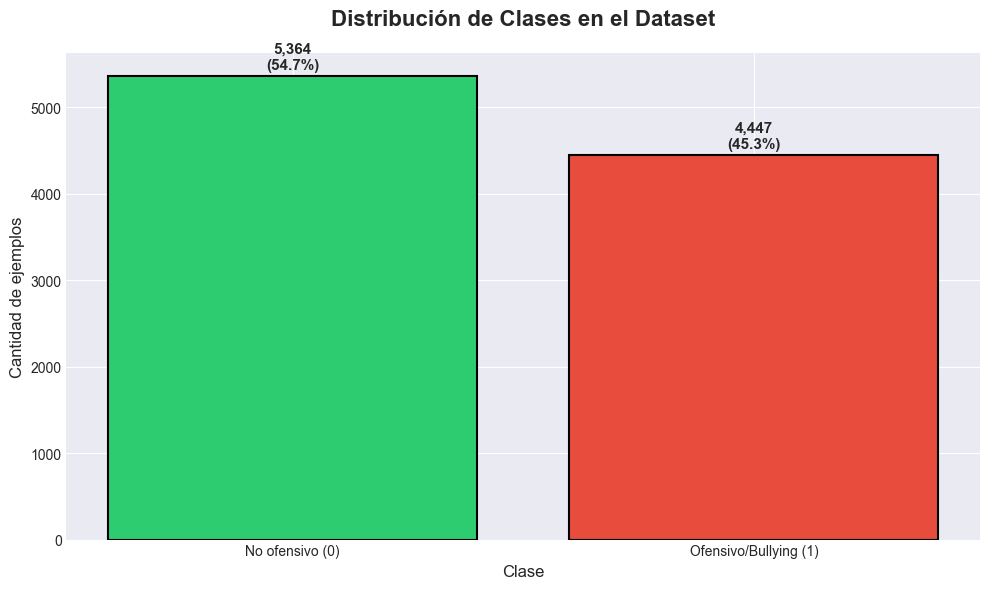

In [4]:
print("="*70)
print("DISTRIBUCIÓN DE CLASES")
print("="*70)

# Contar por clase
distribucion = df['label'].value_counts().sort_index()

print(f"\nCantidad por clase:")
for label, count in distribucion.items():
    pct = (count / len(df)) * 100
    nombre = "No ofensivo" if label == 0 else "Ofensivo/Bullying"
    print(f"   Clase {label} ({nombre}): {count:,} ejemplos ({pct:.1f}%)")

# Calcular ratio de balanceo
ratio = max(distribucion) / min(distribucion)
print(f"\n Ratio de balanceo: {ratio:.2f}:1")

if ratio < 1.5:
    print("    Dataset bien balanceado")
elif ratio < 2.5:
    print("    Ligeramente desbalanceado (aceptable)")
else:
    print("    Dataset muy desbalanceado (considerar balancear)")

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    ['No ofensivo (0)', 'Ofensivo/Bullying (1)'],
    distribucion.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    linewidth=1.5
)

ax.set_title('Distribución de Clases en el Dataset', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Cantidad de ejemplos', fontsize=12)
ax.set_xlabel('Clase', fontsize=12)

# Añadir valores en las barras
for i, (bar, value) in enumerate(zip(bars, distribucion.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 50,
            f'{value:,}\n({value/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 4. Distribución por Fuente

 DISTRIBUCIÓN POR FUENTE

 Ejemplos por fuente:
   zenodo: 5,999 ejemplos (61.1%)
   kaggle_traducido: 1,916 ejemplos (19.5%)
   kaggle_traducido_bullying: 1,896 ejemplos (19.3%)


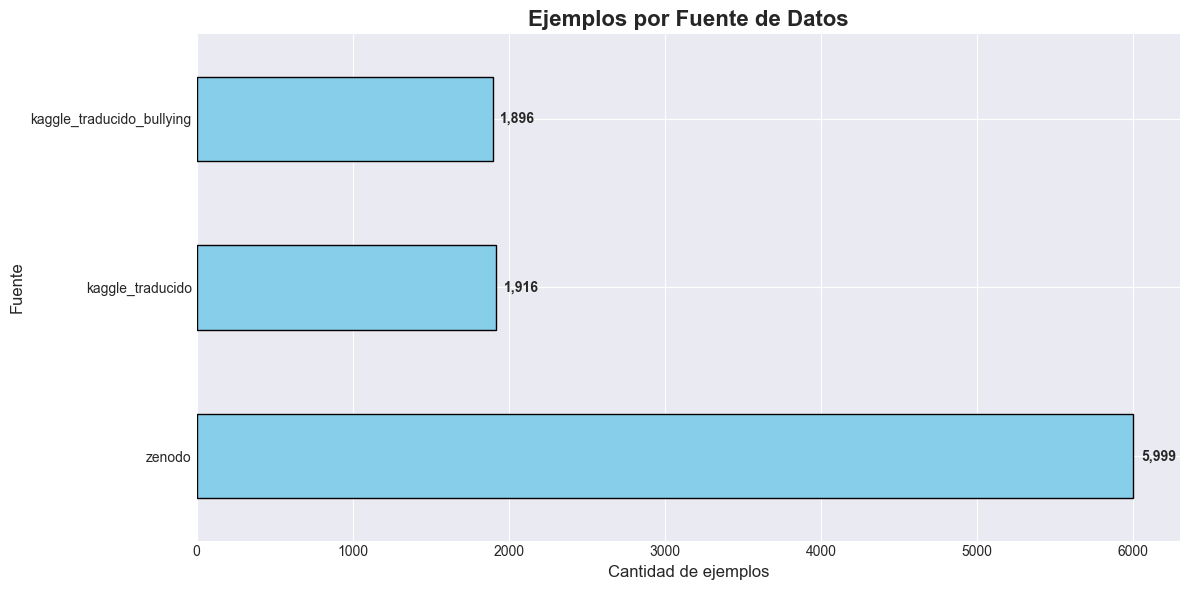

In [5]:
print("="*70)
print(" DISTRIBUCIÓN POR FUENTE")
print("="*70)

fuentes = df['fuente'].value_counts()

print(f"\n Ejemplos por fuente:")
for fuente, count in fuentes.items():
    pct = (count / len(df)) * 100
    print(f"   {fuente}: {count:,} ejemplos ({pct:.1f}%)")

# Visualizar
fig, ax = plt.subplots(figsize=(12, 6))
fuentes.plot(kind='barh', ax=ax, color='skyblue', edgecolor='black')
ax.set_title('Ejemplos por Fuente de Datos', fontsize=16, fontweight='bold')
ax.set_xlabel('Cantidad de ejemplos', fontsize=12)
ax.set_ylabel('Fuente', fontsize=12)

# Añadir valores
for i, v in enumerate(fuentes.values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Análisis de Longitud de Textos

 ANÁLISIS DE LONGITUD DE TEXTOS

 Estadísticas de longitud (caracteres):
count    9811.000000
mean      126.751809
std        67.169773
min         5.000000
25%        82.000000
50%       121.000000
75%       144.000000
max       573.000000
Name: longitud_chars, dtype: float64

 Estadísticas de longitud (palabras):
count    9811.000000
mean       20.332994
std        11.644694
min         1.000000
25%        13.000000
50%        19.000000
75%        24.000000
max        93.000000
Name: longitud_palabras, dtype: float64

 Longitud promedio por clase:
   No ofensivo: 111.5 caracteres, 17.6 palabras
   Ofensivo/Bullying: 145.2 caracteres, 23.7 palabras


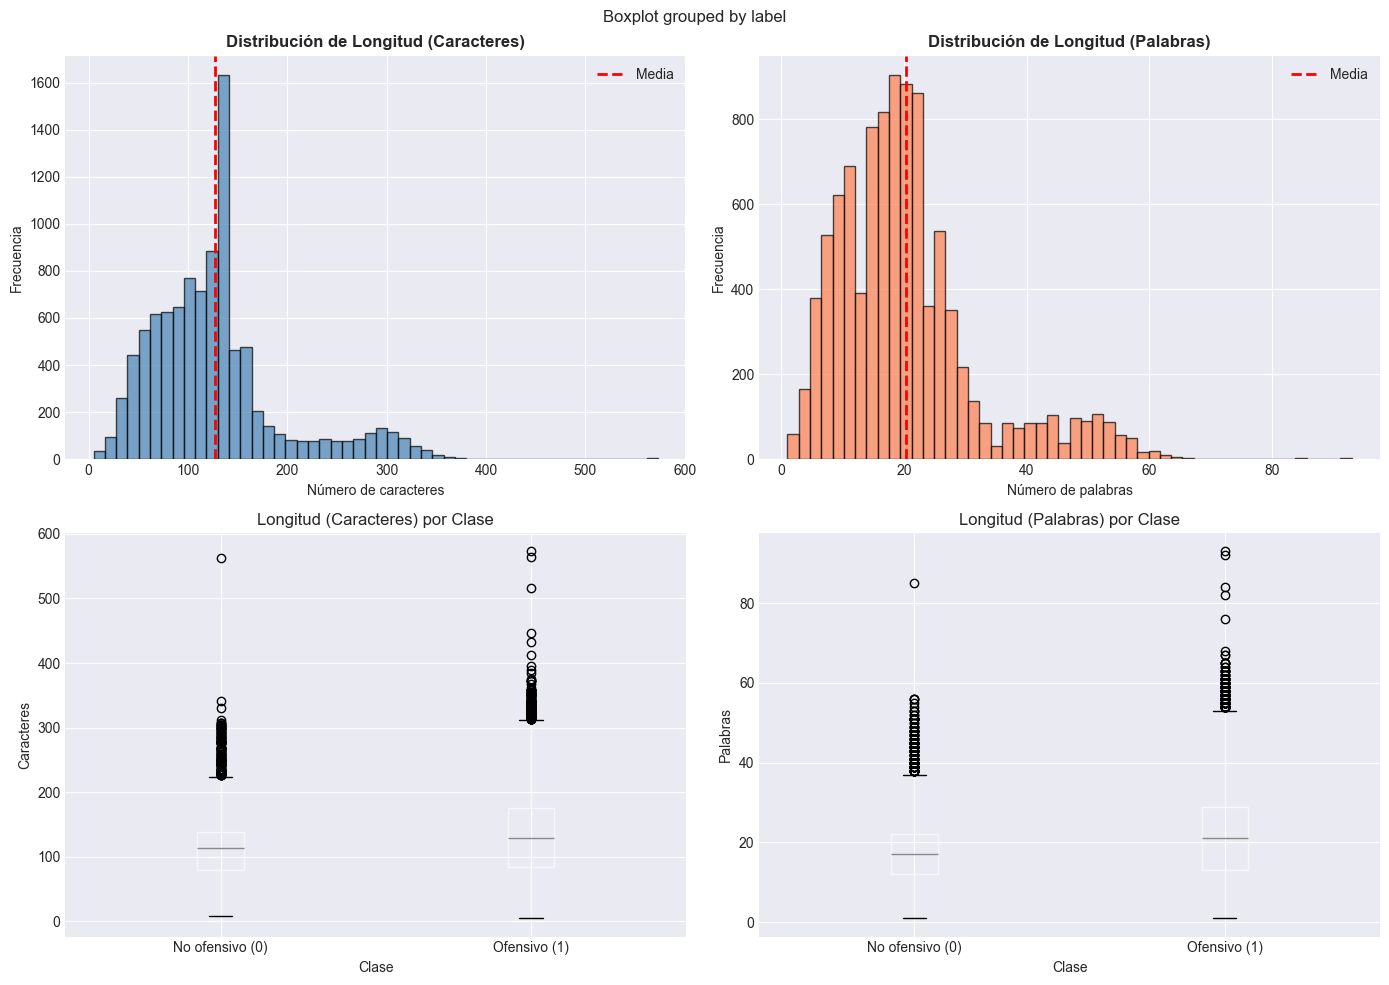

In [6]:
print("="*70)
print(" ANÁLISIS DE LONGITUD DE TEXTOS")
print("="*70)

# Calcular longitudes
df['longitud_chars'] = df['texto'].str.len()
df['longitud_palabras'] = df['texto'].str.split().str.len()

print(f"\n Estadísticas de longitud (caracteres):")
print(df['longitud_chars'].describe())

print(f"\n Estadísticas de longitud (palabras):")
print(df['longitud_palabras'].describe())

# Comparar por clase
print(f"\n Longitud promedio por clase:")
for label in sorted(df['label'].unique()):
    nombre = "No ofensivo" if label == 0 else "Ofensivo/Bullying"
    avg_chars = df[df['label']==label]['longitud_chars'].mean()
    avg_words = df[df['label']==label]['longitud_palabras'].mean()
    print(f"   {nombre}: {avg_chars:.1f} caracteres, {avg_words:.1f} palabras")

# Visualizar
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma de caracteres
axes[0, 0].hist(df['longitud_chars'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución de Longitud (Caracteres)', fontweight='bold')
axes[0, 0].set_xlabel('Número de caracteres')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].axvline(df['longitud_chars'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[0, 0].legend()

# Histograma de palabras
axes[0, 1].hist(df['longitud_palabras'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución de Longitud (Palabras)', fontweight='bold')
axes[0, 1].set_xlabel('Número de palabras')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].axvline(df['longitud_palabras'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[0, 1].legend()

# Boxplot por clase (caracteres)
df.boxplot(column='longitud_chars', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Longitud (Caracteres) por Clase')
axes[1, 0].set_xlabel('Clase')
axes[1, 0].set_ylabel('Caracteres')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['No ofensivo (0)', 'Ofensivo (1)'])

# Boxplot por clase (palabras)
df.boxplot(column='longitud_palabras', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Longitud (Palabras) por Clase')
axes[1, 1].set_xlabel('Clase')
axes[1, 1].set_ylabel('Palabras')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['No ofensivo (0)', 'Ofensivo (1)'])

plt.tight_layout()
plt.show()

## 6. Ejemplos del Dataset

In [7]:
print("="*70)
print(" EJEMPLOS ALEATORIOS DEL DATASET")
print("="*70)

print("\n CLASE 0 (No ofensivo) - 20 ejemplos aleatorios:")
print("-" * 70)
for i, texto in enumerate(df[df['label']==0]['texto'].sample(20, random_state=42).values, 1):
    print(f"{i:2d}. {texto}")

print("\n CLASE 1 (Ofensivo/Bullying) - 20 ejemplos aleatorios:")
print("-" * 70)
for i, texto in enumerate(df[df['label']==1]['texto'].sample(20, random_state=42).values, 1):
    print(f"{i:2d}. {texto}")

 EJEMPLOS ALEATORIOS DEL DATASET

 CLASE 0 (No ofensivo) - 20 ejemplos aleatorios:
----------------------------------------------------------------------
 1. @xoxoMs_smith nunca atiendes a un negro donde duermes con la policía, estás en tu puerta y negro, no intentas ver eso
 2. A parte de que el PSG hace el subnormal, el robo es espectacular.
 3. La Santamaria dient-nos independentista descabezados. Per no recordar-nos que tenen rei. Rei guillotina. Pi i pel.
 4. .@jponcerivero recuerda el tuit de @GrainneMaguire :"Es triste que haya más negros en la tripa de Beyoncé que en el gabinete de Trump"
 5. Alguien dijo hoy que Pete Evans de #mkr nunca ha sido filmado metiéndose comida en la boca. ¿Es esto cierto?
 6. He perdido un par de horas discutiendo con una parodia de persona desesperada. Soy subnormal de película, pero de los que no ganan el OSCAR.
 7. En el colegio, teniendo aproximadamente 10 años, unos niños me escribieron "maricón" en la nuca, pero tranquilos, e… https://t.co/G0Xk